#  Hospital Readmission Risk Analytics
## Notebook 4: XGBoost + SHAP Explainability + Model Comparison
### Diabetes 130-US Hospitals Dataset

---

###  Why XGBoost?

**XGBoost (eXtreme Gradient Boosting)** is consistently one of the top-performing
algorithms on tabular clinical data. Unlike Random Forest (parallel trees),
XGBoost builds trees **sequentially**, each one correcting the errors of the last.

**Key advantages:**
- **Gradient boosting** — directly optimises the loss function
- **Regularisation** (L1 + L2) — reduces overfitting on noisy clinical data
- **Handles missing values** natively — no imputation needed
- **Scale-invariant** — no need to normalise features
- **Built-in early stopping** — prevents overtraining automatically

---

###  Why SHAP?

**SHAP (SHapley Additive exPlanations)** provides the gold standard for ML explainability.
Based on game theory, SHAP fairly distributes the model's prediction among each feature.

For each patient, SHAP answers: **"Why did the model predict this readmission risk?"**

This is critical for clinical adoption — clinicians must understand *why* a patient
is flagged before acting on the model's recommendation.

---

###  Notebook Goals
1. Train XGBoost with early stopping
2. Full evaluation + comparison against LR and RF
3. SHAP global summary and bar plots
4. SHAP waterfall plot — **individual patient explanation**
5. SHAP dependence plots for top features
6. Final model comparison dashboard

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

import xgboost as xgb
import shap

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

#  Load data and shared assets
features = pd.read_csv("../Data/Processed Data/feature_list.csv")["feature"].tolist()
with open("../Outputs/Models/train_test_split.pkl", "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)
with open("../Outputs/Models/lr_model.pkl", "rb") as f: lr = pickle.load(f)
with open("../Outputs/Models/rf_model.pkl", "rb") as f: rf = pickle.load(f)
with open("../Outputs/Models/scaler.pkl", "rb") as f: scaler = pickle.load(f)

print(f" All models + data loaded")
print(f"   Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"   XGBoost version: {xgb.__version__}")
print(f"   SHAP version   : {shap.__version__}")

 All models + data loaded
   Train: (55997, 31)  |  Test: (14000, 31)
   XGBoost version: 3.2.0
   SHAP version   : 0.51.0


---
## 1. Train XGBoost with Early Stopping

In [11]:
from sklearn.model_selection import train_test_split as tts
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb


# Validation split for early stopping

X_tr, X_val, y_tr, y_val = tts(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)


# Class imbalance handling

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

spw = neg / pos if pos > 0 else 1

print(f"scale_pos_weight = {spw:.2f}")


# Model WITH early stopping

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="auc",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("\n✅ XGBoost trained")
print(f"Best iteration : {xgb_model.best_iteration}")
print(f"Best AUC (val) : {xgb_model.best_score:.4f}")


# CLEAN model for cross-validation

xgb_cv_model = xgb.XGBClassifier(
    n_estimators=xgb_model.best_iteration,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)


# Cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_aucs = cross_val_score(
    xgb_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print(f"\n5-Fold CV AUC : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")

scale_pos_weight = 10.14

✅ XGBoost trained
Best iteration : 44
Best AUC (val) : 0.6492

5-Fold CV AUC : 0.6489 ± 0.0151


---
## 2. Test Set Evaluation

In [12]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

auc = roc_auc_score(y_test, y_prob)
ap  = average_precision_score(y_test, y_prob)

print("=" * 55)
print("XGBOOST — TEST SET PERFORMANCE")
print("=" * 55)
print(f"  AUC-ROC                    : {auc:.4f}")
print(f"  Average Precision (PR-AUC) : {ap:.4f}")
print()
print(classification_report(
    y_test, y_pred,
    target_names=["Not Readmitted", "Readmitted <30"]
))

XGBOOST — TEST SET PERFORMANCE
  AUC-ROC                    : 0.6476
  Average Precision (PR-AUC) : 0.1764

                precision    recall  f1-score   support

Not Readmitted       0.94      0.68      0.79     12743
Readmitted <30       0.14      0.52      0.22      1257

      accuracy                           0.67     14000
     macro avg       0.54      0.60      0.51     14000
  weighted avg       0.86      0.67      0.74     14000



<Figure size 704x528 with 0 Axes>

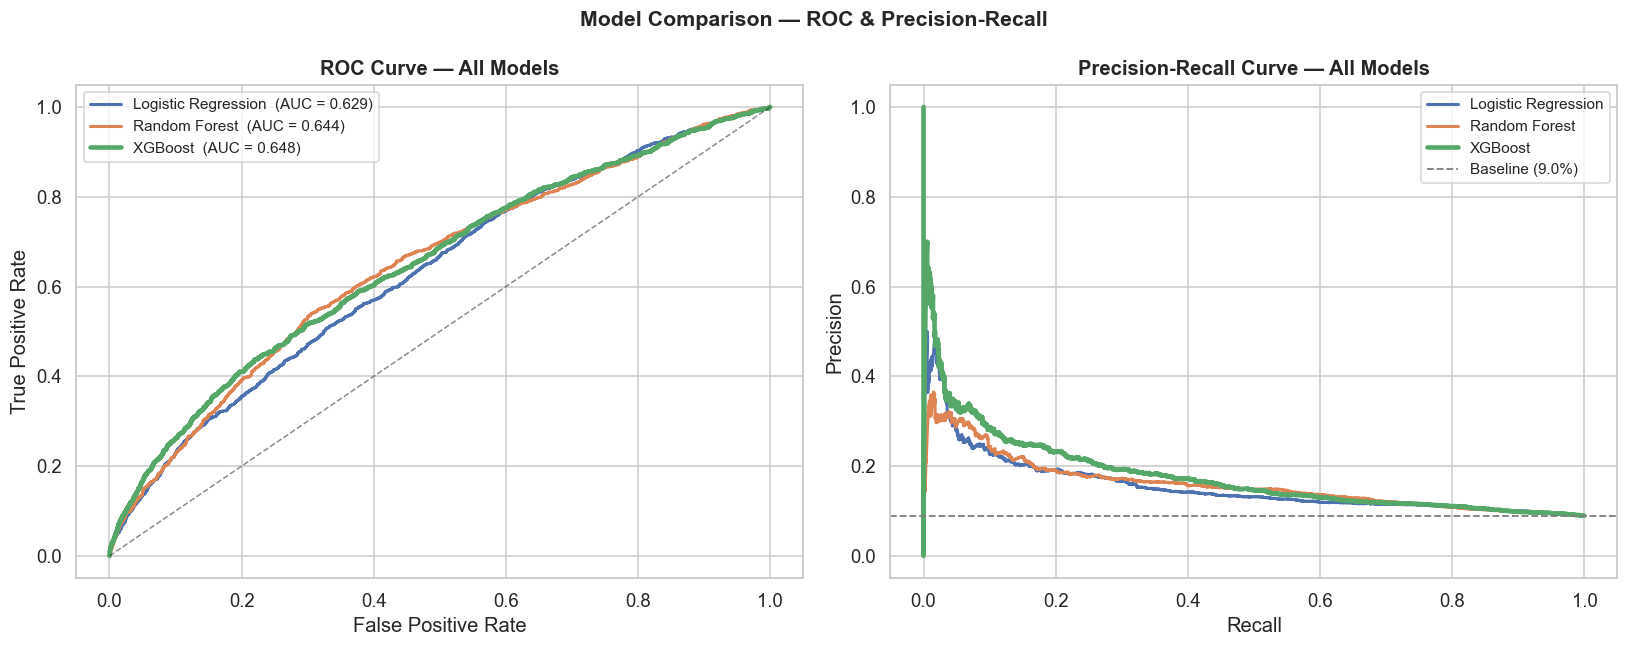


 Model Comparison Plot saved to outputs/figures/


In [32]:
# Three-way ROC comparison
X_test_sc = scaler.transform(X_test)
lr_prob   = lr.predict_proba(X_test_sc)[:, 1]
rf_prob   = rf.predict_proba(X_test)[:, 1]

lr_auc    = roc_auc_score(y_test, lr_prob)
rf_auc    = roc_auc_score(y_test, rf_prob)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette   = {"Logistic Regression": "#4C72B0",
             "Random Forest": "#DD8452",
             "XGBoost": "#55A868"}

for name, prob, model_auc in [
    ("Logistic Regression", lr_prob, lr_auc),
    ("Random Forest",       rf_prob, rf_auc),
    ("XGBoost",             y_prob,  auc),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    lw = 3 if name == "XGBoost" else 2
    axes[0].plot(fpr, tpr, lw=lw, color=palette[name],
                 label=f"{name}  (AUC = {model_auc:.3f})")

axes[0].plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — All Models", fontweight="bold")
axes[0].legend(fontsize=10)

for name, prob in [("Logistic Regression", lr_prob),
                    ("Random Forest", rf_prob),
                    ("XGBoost", y_prob)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    lw = 3 if name == "XGBoost" else 2
    axes[1].plot(rec, prec, lw=lw, color=palette[name], label=name)
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", lw=1.2,
                label=f"Baseline ({y_test.mean()*100:.1f}%)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — All Models", fontweight="bold")
axes[1].legend(fontsize=10)

plt.suptitle("Model Comparison — ROC & Precision-Recall", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

plt.savefig(
    "Outputs/figures/ROC_Precision_Recall.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Model Comparison Plot saved to outputs/figures/")

---
## 3. SHAP Global Explainability

SHAP values tell us **how much each feature contributes** to the model's predictions,
averaged across all patients. This is the most trusted method for ML explainability.

In [14]:
# SHAP TreeExplainer is optimised for tree-based models (XGBoost, RF)
explainer   = shap.TreeExplainer(xgb_model)

# Compute SHAP values on test set (sample 2000 for speed)
np.random.seed(42)
sample_idx  = np.random.choice(len(X_test), size=2000, replace=False)
X_sample    = X_test.iloc[sample_idx].reset_index(drop=True)

shap_values = explainer(X_sample)

print(f" SHAP values computed for {len(X_sample):,} test patients")
print(f"   SHAP values shape: {shap_values.values.shape}")

✅ SHAP values computed for 2,000 test patients
   SHAP values shape: (2000, 31)


SHAP Summary Plot (Beeswarm) — Top 20 Features
  Red  = high feature value | Blue = low feature value
  Right of 0 = pushes prediction toward readmission
  Left  of 0 = pushes prediction away from readmission



<Figure size 704x528 with 0 Axes>

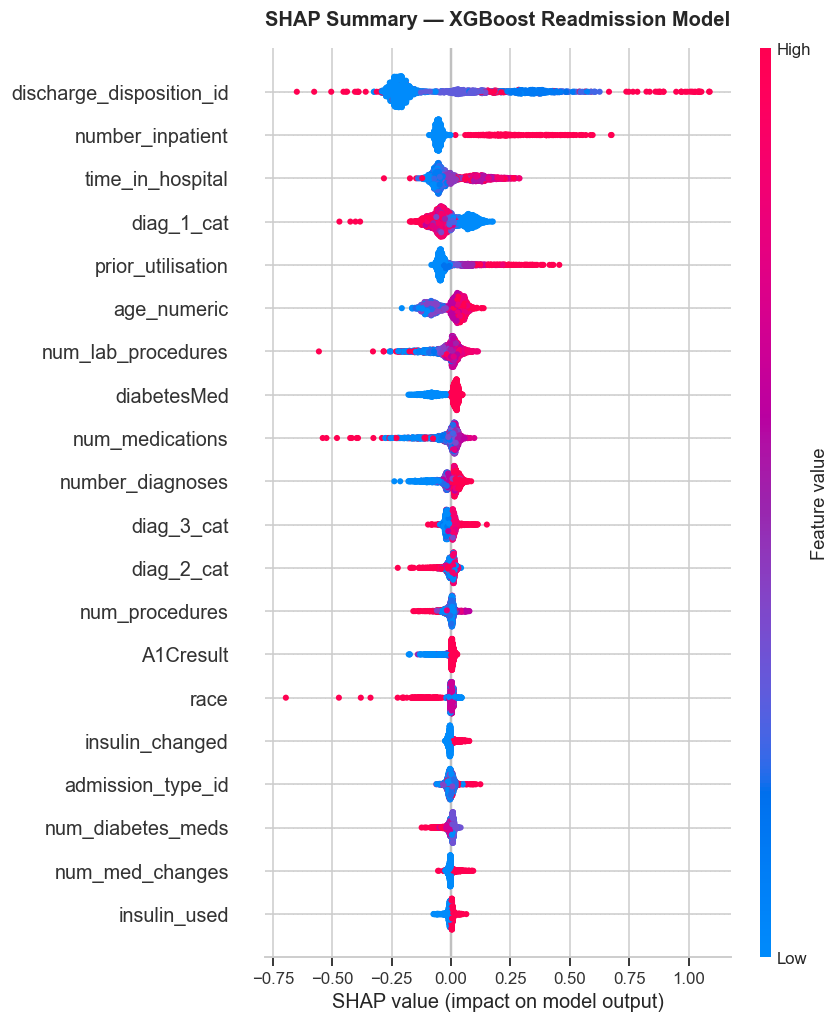


 SHAP Summary Plot saved to outputs/figures/


In [31]:
# ── SHAP Summary Plot (beeswarm)
# Shows: which features matter AND how their values affect predictions
# Each dot = one patient; colour = feature value; x-axis = SHAP value impact
print("SHAP Summary Plot (Beeswarm) — Top 20 Features")
print("  Red  = high feature value | Blue = low feature value")
print("  Right of 0 = pushes prediction toward readmission")
print("  Left  of 0 = pushes prediction away from readmission\n")

plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title("SHAP Summary — XGBoost Readmission Model", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

plt.savefig(
    "Outputs/figures/XGBoost_Readmission_Model.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n SHAP Summary Plot saved to outputs/figures/")

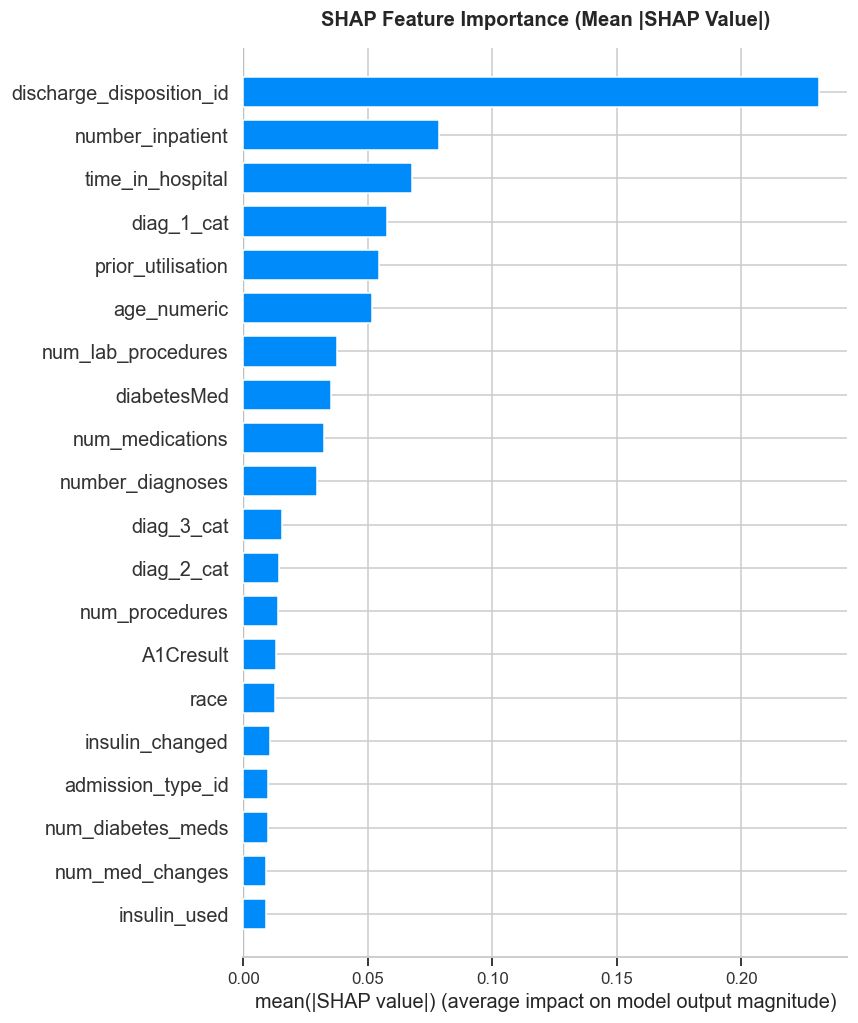


 SHAP Feature Importance Plot saved to outputs/figures/
Top 15 features by mean |SHAP|:
discharge_disposition_id    0.2311
number_inpatient            0.0786
time_in_hospital            0.0676
diag_1_cat                  0.0579
prior_utilisation           0.0545
age_numeric                 0.0517
num_lab_procedures          0.0376
diabetesMed                 0.0352
num_medications             0.0322
number_diagnoses            0.0297
diag_3_cat                  0.0155
diag_2_cat                  0.0144
num_procedures              0.0138
A1Cresult                   0.0131
race                        0.0127


In [30]:
# SHAP Bar Plot (mean absolute SHAP values)
# Simpler view: overall feature importance ranked by mean |SHAP|
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar",
                  max_display=20, show=False)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

plt.savefig(
    "Outputs/figures/SHAP_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n SHAP Feature Importance Plot saved to outputs/figures/")
# Print top 15 numerically
mean_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=features
).sort_values(ascending=False)
print("Top 15 features by mean |SHAP|:")
print(mean_shap.head(15).round(4).to_string())

---
## 4. SHAP Dependence Plots

Dependence plots show **how a feature's SHAP impact changes with its value**.
The colour represents a second feature (automatically chosen — often the most interacting feature).


 SHAP Dependence Plots saved to outputs/figures/


<Figure size 704x528 with 0 Axes>

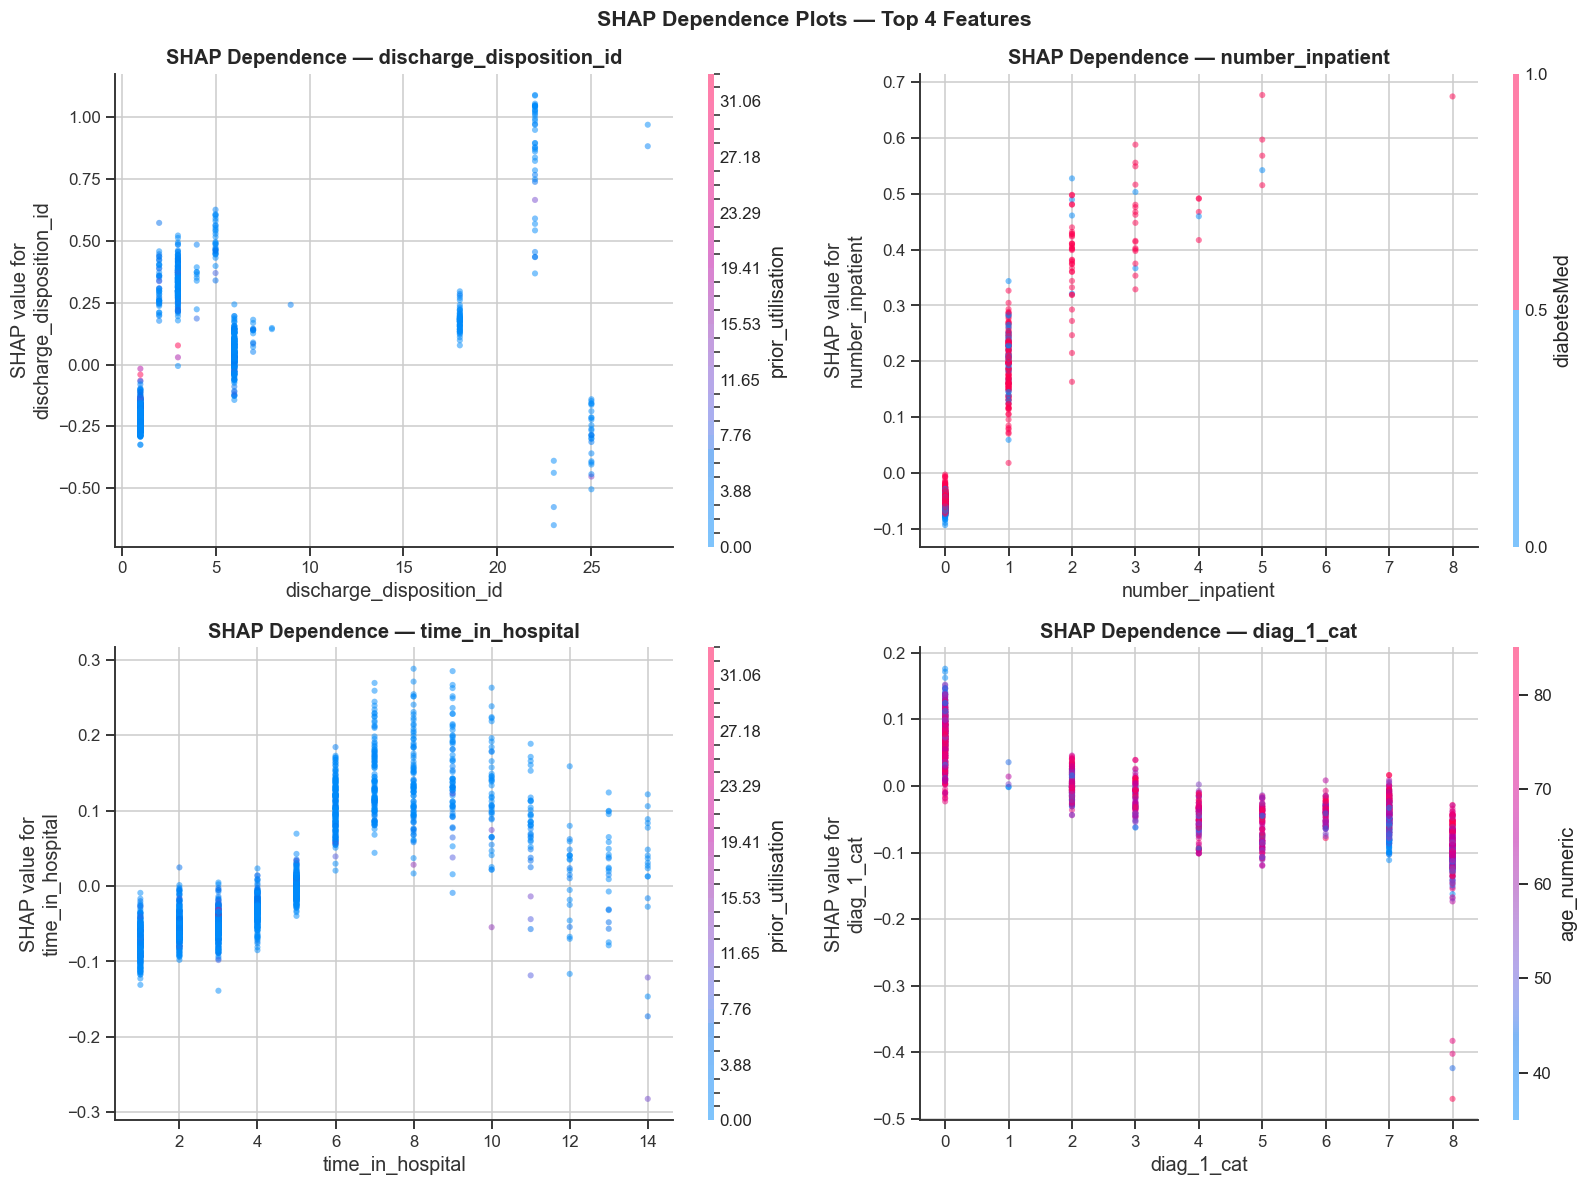

In [29]:
top_features = mean_shap.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    shap.dependence_plot(
        feat, shap_values.values, X_sample,
        ax=axes[i], show=False, alpha=0.5
    )
    axes[i].set_title(f"SHAP Dependence — {feat}", fontweight="bold")

plt.suptitle("SHAP Dependence Plots — Top 4 Features", fontsize=14, fontweight="bold")
plt.savefig(
    "Outputs/figures/Top_4_features .png",
    dpi=300,
    bbox_inches="tight"
)

print("\n SHAP Dependence Plots saved to outputs/figures/")
plt.tight_layout()
plt.show()

---
## 5. Individual Patient Explanation (Waterfall Plot)

This is the most **clinically actionable** output: for a single high-risk patient,
which specific features drove their readmission risk score?

Selected patient:
  Sample index        : 308
  Predicted risk      : 82.4%
  Actual outcome      : Not Readmitted


<Figure size 704x528 with 0 Axes>

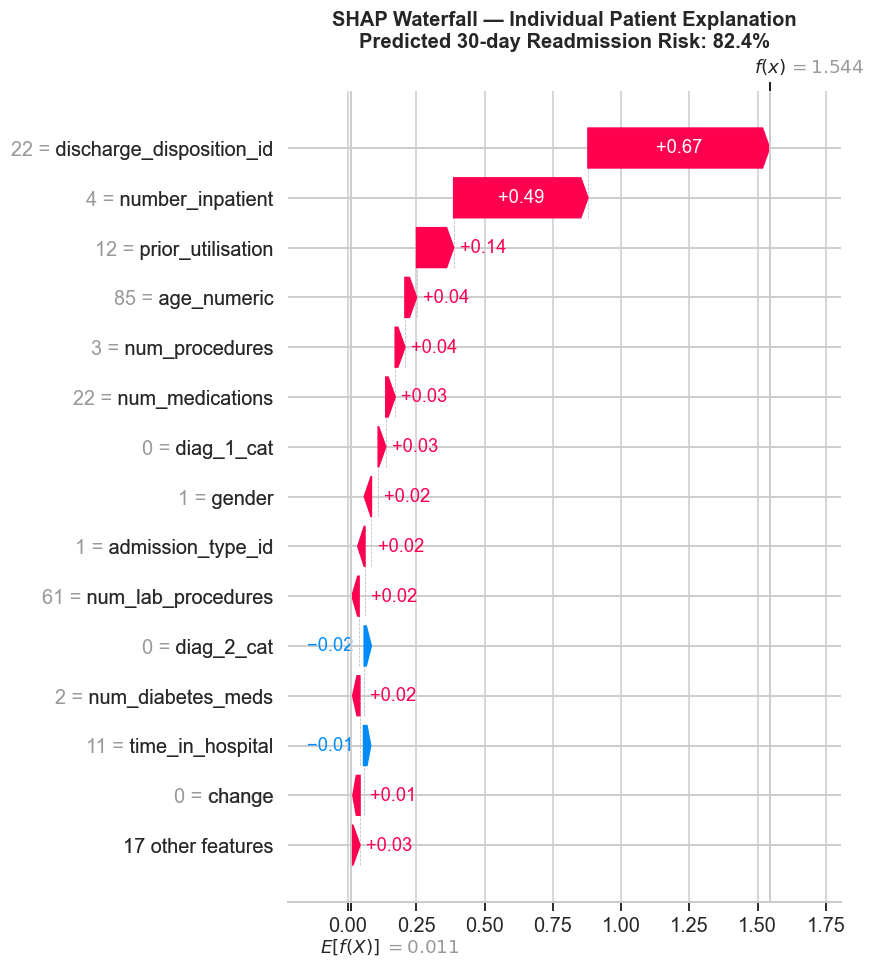


 SHAP Waterfall Plot saved to outputs/figures/

 How to read this:
   E[f(x)] = average model output (base rate)
   f(x)    = this patient's predicted probability
   Red bars = features pushing risk UP
   Blue bars = features pushing risk DOWN


In [28]:
# Find a high-risk patient in the test set
high_risk_mask = y_prob[sample_idx] > 0.6
if high_risk_mask.sum() == 0:
    high_risk_mask = y_prob[sample_idx] > y_prob[sample_idx].quantile(0.90)

# Pick the highest-risk patient
patient_idx = int(np.argmax(y_prob[sample_idx]))
patient_prob = y_prob[sample_idx[patient_idx]]

print(f"Selected patient:")
print(f"  Sample index        : {patient_idx}")
print(f"  Predicted risk      : {patient_prob*100:.1f}%")
print(f"  Actual outcome      : {'Readmitted' if y_test.iloc[sample_idx[patient_idx]] == 1 else 'Not Readmitted'}")

# Waterfall plot — shows how each feature pushes from expected value to this prediction
plt.figure(figsize=(11, 8))
shap.plots.waterfall(shap_values[patient_idx], max_display=15, show=False)
plt.title(f"SHAP Waterfall — Individual Patient Explanation\n"
          f"Predicted 30-day Readmission Risk: {patient_prob*100:.1f}%",
          fontweight="bold")
plt.tight_layout()
plt.show()

plt.savefig(
    "Outputs/figures/Individual_Patient_Explanation_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n SHAP Waterfall Plot saved to outputs/figures/")
print("\n How to read this:")
print("   E[f(x)] = average model output (base rate)")
print("   f(x)    = this patient's predicted probability")
print("   Red bars = features pushing risk UP")
print("   Blue bars = features pushing risk DOWN")

SHAP Force Plot — Same Patient
(Shows feature contributions as a horizontal stack)



<Figure size 704x528 with 0 Axes>

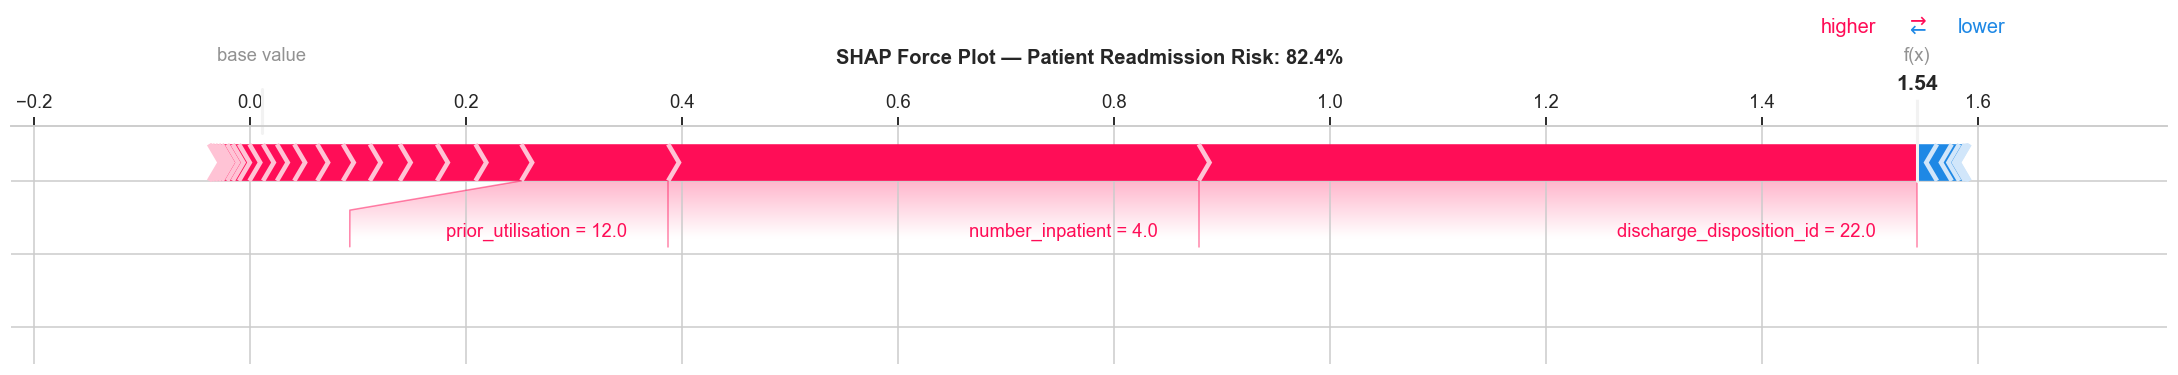


✅ SHAP Force Plot saved to outputs/figures/


In [27]:
#  Force plot for same patient (alternative view)
print("SHAP Force Plot — Same Patient")
print("(Shows feature contributions as a horizontal stack)\n")
shap.initjs()
force = shap.force_plot(
    explainer.expected_value,
    shap_values.values[patient_idx],
    X_sample.iloc[patient_idx],
    feature_names=features,
    matplotlib=True,
    show=False,
    figsize=(20, 4)
)
plt.title(f"SHAP Force Plot — Patient Readmission Risk: {patient_prob*100:.1f}%",
          fontweight="bold", pad=20)
plt.tight_layout()
plt.show()
# Save SHAP force plot
plt.savefig(
    "Outputs/figures/Patient_Readmission_Risk_SHAP_Force_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n SHAP Force Plot saved to outputs/figures/")

---
## 6. Final Model Comparison Dashboard

In [20]:
#  Save XGBoost + update results
with open("../Outputs/Models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

prev = pd.read_csv("../Data/Processed Data/model_results.csv")
new_row = pd.DataFrame([{
    "Model"           : "XGBoost",
    "AUC_ROC"         : round(auc, 4),
    "Avg_Precision"   : round(ap, 4),
    "CV_AUC_Mean"     : round(cv_aucs.mean(), 4),
    "CV_AUC_Std"      : round(cv_aucs.std(), 4),
    "Precision_class1": round(precision_score(y_test, y_pred), 4),
    "Recall_class1"   : round(recall_score(y_test, y_pred), 4),
    "F1_class1"       : round(f1_score(y_test, y_pred), 4),
}])
all_results = pd.concat([prev, new_row], ignore_index=True)
all_results.to_csv("model_results.csv", index=False)
print("Model Results Table:")
print(all_results.to_string(index=False))

Model Results Table:
              Model  AUC_ROC  Avg_Precision  CV_AUC_Mean  CV_AUC_Std  Precision_class1  Recall_class1  F1_class1
Logistic Regression   0.6289         0.1552       0.6232      0.0141            0.1276         0.5338     0.2059
      Random Forest   0.6444         0.1595       0.6399      0.0142            0.1729         0.2991     0.2191
      Random Forest   0.6444         0.1595       0.6399      0.0142            0.1729         0.2991     0.2191
            XGBoost   0.6476         0.1764       0.6489      0.0151            0.1406         0.5235     0.2217


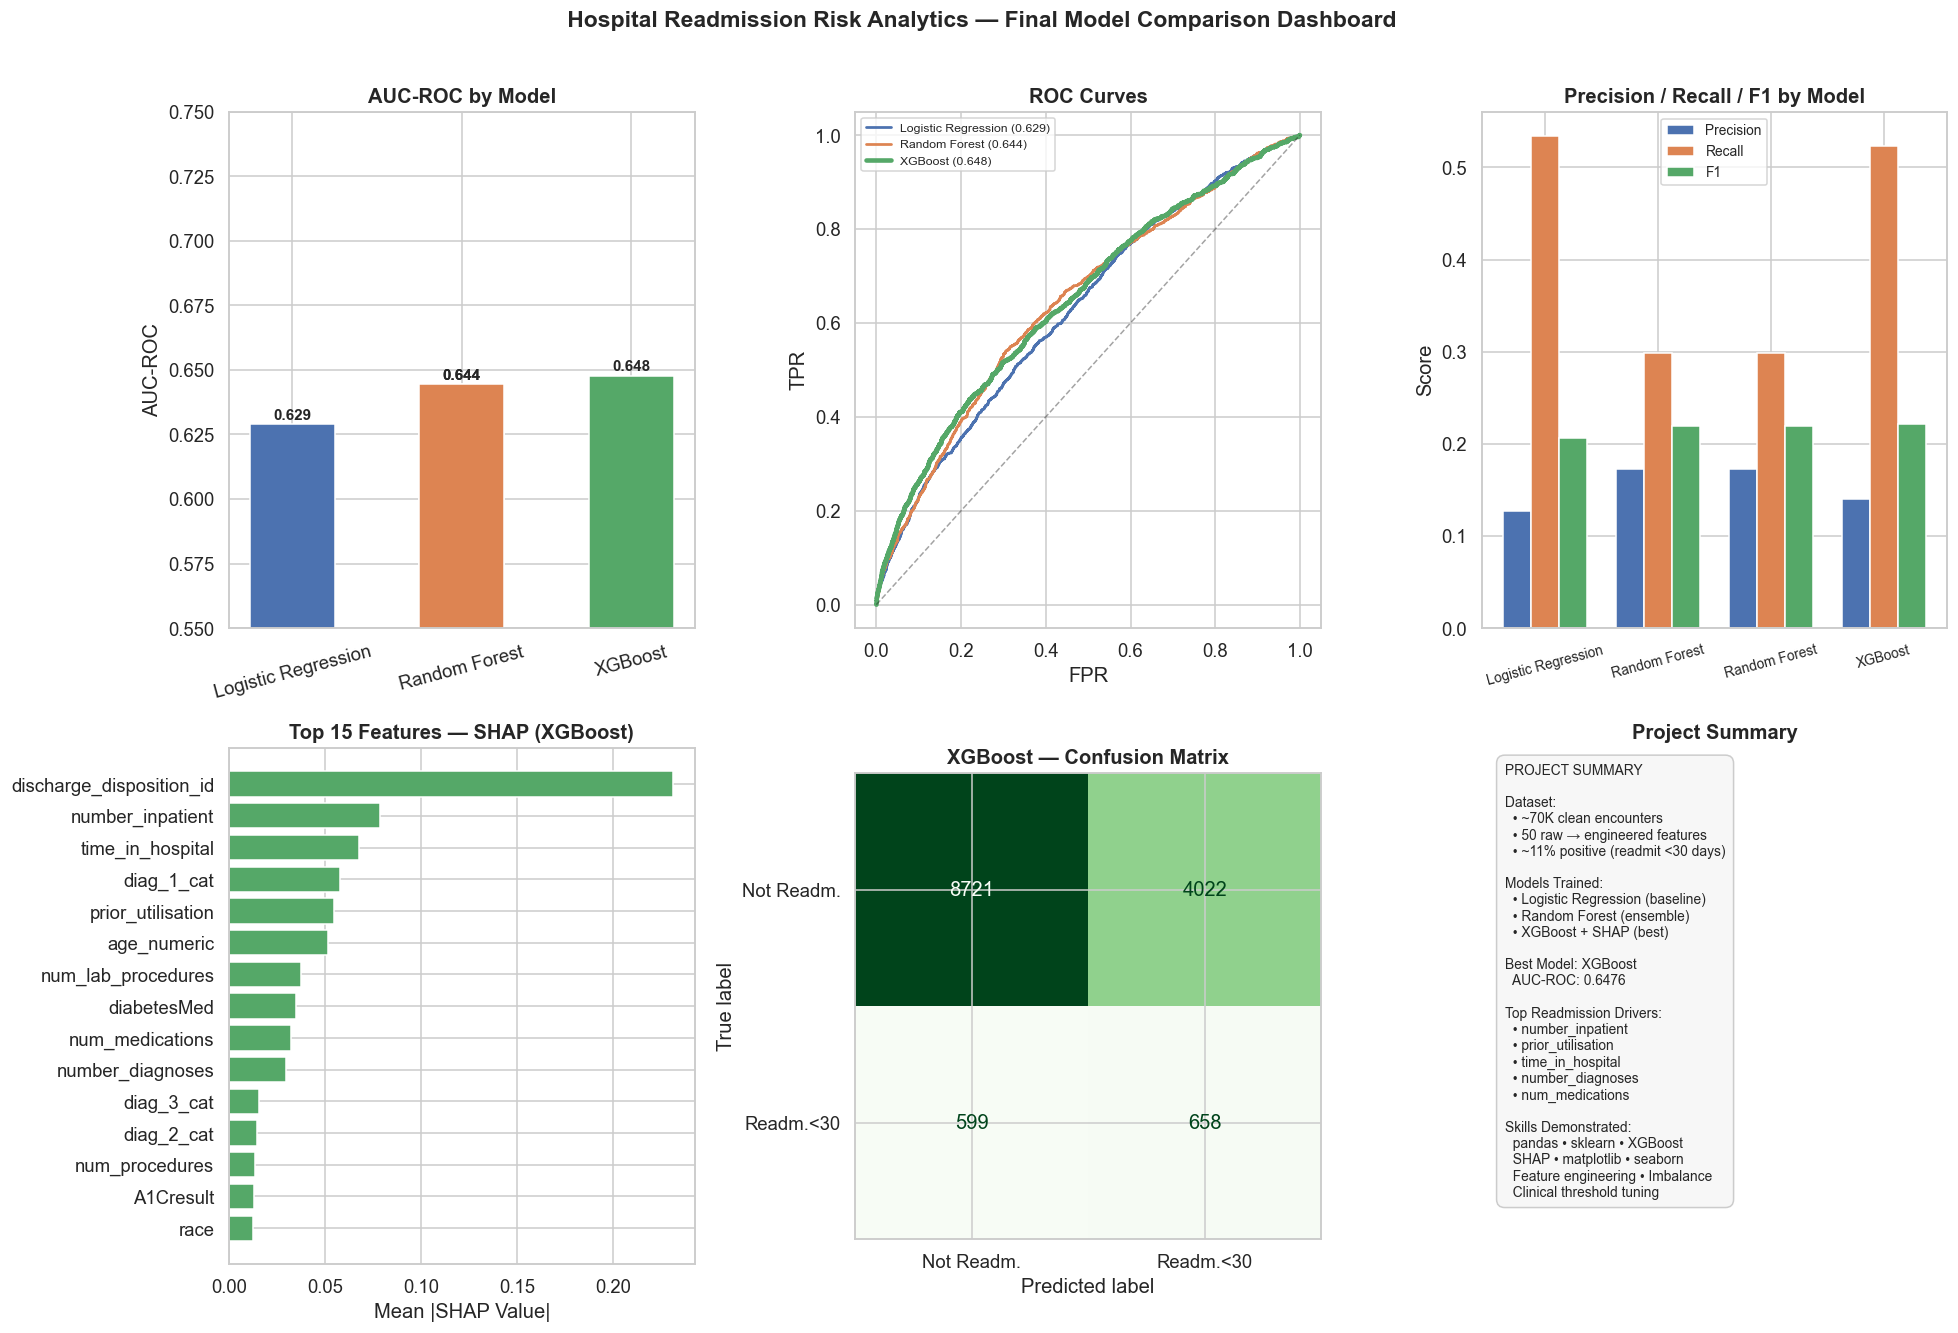


 Dashboard saved: readmission_dashboard_summary.png


In [22]:
#  Final comparison dashboard
fig = plt.figure(figsize=(18, 12))
fig.suptitle(" Hospital Readmission Risk Analytics — Final Model Comparison Dashboard",
             fontsize=15, fontweight="bold", y=1.01)

colors_m  = {"Logistic Regression": "#4C72B0",
             "Random Forest":       "#DD8452",
             "XGBoost":             "#55A868"}

#  Panel 1: AUC-ROC bar chart
ax1 = fig.add_subplot(2, 3, 1)
models = all_results["Model"].tolist()
aucs   = all_results["AUC_ROC"].tolist()
bars   = ax1.bar(models, aucs,
                 color=[colors_m[m] for m in models],
                 edgecolor="white", width=0.5)
ax1.set_ylim(0.55, 0.75)
ax1.set_title("AUC-ROC by Model", fontweight="bold")
ax1.set_ylabel("AUC-ROC")
ax1.tick_params(axis="x", rotation=15)
for bar, v in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.002,
             f"{v:.3f}", ha="center", fontweight="bold", fontsize=10)

#  Panel 2: ROC curves
ax2 = fig.add_subplot(2, 3, 2)
for name, prob, model_auc in [
    ("Logistic Regression", lr_prob, lr_auc),
    ("Random Forest",       rf_prob, rf_auc),
    ("XGBoost",             y_prob,  auc),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    lw = 3 if name == "XGBoost" else 1.8
    ax2.plot(fpr, tpr, lw=lw, color=colors_m[name],
             label=f"{name} ({model_auc:.3f})")
ax2.plot([0,1],[0,1],"k--",lw=1,alpha=0.4)
ax2.set_title("ROC Curves", fontweight="bold")
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.legend(fontsize=8)

#  Panel 3: F1 / Precision / Recall bar chart
ax3 = fig.add_subplot(2, 3, 3)
x = np.arange(len(models))
w = 0.25
for i, (metric, label) in enumerate([
    ("Precision_class1", "Precision"),
    ("Recall_class1",    "Recall"),
    ("F1_class1",        "F1"),
]):
    ax3.bar(x + i*w, all_results[metric], width=w, label=label, edgecolor="white")
ax3.set_xticks(x + w); ax3.set_xticklabels(models, rotation=15, fontsize=9)
ax3.set_title("Precision / Recall / F1 by Model", fontweight="bold")
ax3.set_ylabel("Score"); ax3.legend(fontsize=9)

#  Panel 4: SHAP feature importance
ax4 = fig.add_subplot(2, 3, 4)
top15_shap = mean_shap.head(15)
ax4.barh(top15_shap.index[::-1], top15_shap.values[::-1],
         color="#55A868", edgecolor="white")
ax4.set_title("Top 15 Features — SHAP (XGBoost)", fontweight="bold")
ax4.set_xlabel("Mean |SHAP Value|")

#  Panel 5: XGBoost confusion matrix
ax5 = fig.add_subplot(2, 3, 5)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Readm.", "Readm.<30"]).plot(
    ax=ax5, colorbar=False, cmap="Greens")
ax5.set_title("XGBoost — Confusion Matrix", fontweight="bold")

#  Panel 6: Summary text
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis("off")
best_model = all_results.loc[all_results["AUC_ROC"].idxmax(), "Model"]
best_auc   = all_results["AUC_ROC"].max()
summary_text = (
    "PROJECT SUMMARY\n\n"
    f"Dataset:\n"
    f"  • ~70K clean encounters\n"
    f"  • 50 raw → engineered features\n"
    f"  • ~11% positive (readmit <30 days)\n\n"
    "Models Trained:\n"
    f"  • Logistic Regression (baseline)\n"
    f"  • Random Forest (ensemble)\n"
    f"  • XGBoost + SHAP (best)\n\n"
    f"Best Model: {best_model}\n"
    f"  AUC-ROC: {best_auc:.4f}\n\n"
    "Top Readmission Drivers:\n"
    f"  • number_inpatient\n"
    f"  • prior_utilisation\n"
    f"  • time_in_hospital\n"
    f"  • number_diagnoses\n"
    f"  • num_medications\n\n"
    "Skills Demonstrated:\n"
    "  pandas • sklearn • XGBoost\n"
    "  SHAP • matplotlib • seaborn\n"
    "  Feature engineering • Imbalance\n"
    "  Clinical threshold tuning"
)
ax6.text(0.05, 0.97, summary_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.6",
                   facecolor="#F7F7F7", edgecolor="#CCCCCC"))
ax6.set_title("Project Summary", fontweight="bold")

plt.tight_layout()
plt.savefig("readmission_dashboard_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("\n Dashboard saved: readmission_dashboard_summary.png")